What is "dirty data"?
Real datasets have problems — missing customer IDs, negative quantities (returns), duplicate rows. You need to clean these before doing anything else.

In [1]:
#load the file

import pandas as pd

# Load data
df = pd.read_csv('Online retail dataset.csv', encoding='latin1')

# Look at first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [2]:
#Clean it — 4 simple steps

# Step 1: Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# Step 2: Remove returns (negative Quantity)
df = df[df['Quantity'] > 0]

# Step 3: Remove rows with no price
df = df[df['Price'] > 0]

# Step 4: Calculate total spend per row
df['TotalSpend'] = df['Quantity'] * df['Price']

print(f"Rows remaining: {len(df)}")

Rows remaining: 793309


RFM Analysis:score every customer

What is RFM? (Simple explanation)
Think of your mobile recharge history. Your telecom company looks at:

R = Recency — Did you recharge last week or 6 months ago?
F = Frequency — Do you recharge every month or rarely?
M = Monetary — Do you spend ₹100 or ₹1000 each time?

A customer who recharged yesterday, does it every month, and spends ₹500 = Champion customer. One who last recharged 1 year ago, rarely, ₹50 = About to leave.

In [3]:
#Create a churn label
#Decide: if a customer hasn't bought in 90+ days, call them "churned" (1). Otherwise "active" (0).


# Use time-split to avoid data leakage
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

cutoff = pd.Timestamp('2011-06-01')  # midpoint of the dataset

first_half = df[df['InvoiceDate'] < cutoff]
second_half = df[df['InvoiceDate'] >= cutoff]

active_in_second = second_half['Customer ID'].unique()

# Rebuild RFM from first half only
rfm = first_half.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (cutoff - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalSpend', 'sum')
).reset_index()

# Churn = didn't come back in second half
rfm['Churn'] = (~rfm['Customer ID'].isin(active_in_second)).astype(int)
print(rfm['Churn'].value_counts())

Churn
0    2566
1    2367
Name: count, dtype: int64


In [4]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)

#calculate RFM
from datetime import datetime

 # Pick a reference date (day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

 # Group by customer and calculate R, F, M
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalSpend', 'sum')
).reset_index()

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      321         12  77556.46
1      12347.0       35          7   5408.50
2      12348.0       71          5   2019.40
3      12349.0       14          4   4428.69
4      12350.0      305          1    334.40


In [5]:
#Give each customer a score 1–5
#Split customers into 5 equal groups. Score 5 = best, Score 1 = worst.

# For Recency: lower days = better (so reverse)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5])

# Combined score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [6]:
#Label customers into segments

def label_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    if r >= 4 and f >= 4: return 'Champion'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'New Customer'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r == 1 and f == 1: return 'Lost'
    else: return 'Needs Attention'

rfm['Segment'] = rfm.apply(label_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champion           1468
Needs Attention    1366
Loyal              1212
At Risk             836
Lost                503
New Customer        475
Name: count, dtype: int64


Churn Prediction - Who will leave?
build a model that predicts customers at risk.
 
"Churn" = a customer stops using your service. For example, if someone hasn't bought anything in 6 months, they have likely "churned." Your goal: predict WHO will churn BEFORE they do, so you can send them a discount or offer to bring them back.

Train a prediction model (XGBoost)
This is like teaching a machine to recognize patterns. You give it examples of churned vs active customers, and it learns to predict new ones.

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# ── Create churn label (must happen BEFORE using rfm['Churn']) ──
cutoff = pd.Timestamp('2011-06-01')

first_half = df[df['InvoiceDate'] < cutoff]
second_half = df[df['InvoiceDate'] >= cutoff]
active_in_second = second_half['Customer ID'].unique()

rfm = first_half.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (cutoff - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalSpend', 'sum')
).reset_index()

rfm['Churn'] = (~rfm['Customer ID'].isin(active_in_second)).astype(int)

# ── Quick check before training ──
print("Churn distribution:")
print(rfm['Churn'].value_counts())
print(f"\nColumns available: {list(rfm.columns)}")

# ── Model ──
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(classification_report(y_test, preds))

Churn distribution:
Churn
0    2566
1    2367
Name: count, dtype: int64

Columns available: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Churn']
              precision    recall  f1-score   support

           0       0.70      0.67      0.68       527
           1       0.64      0.67      0.65       460

    accuracy                           0.67       987
   macro avg       0.67      0.67      0.67       987
weighted avg       0.67      0.67      0.67       987



In [9]:
print(rfm.columns.tolist())
print(rfm.shape)


['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Churn']
(4933, 5)


#Explain the model with SHAP
#SHAP shows you why the model thinks someone will churn

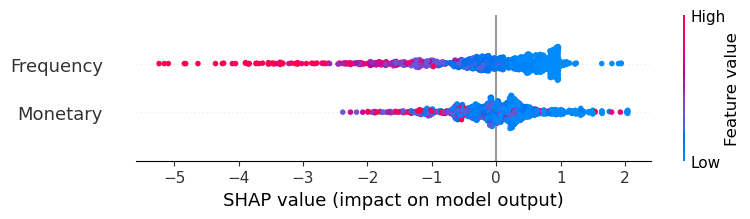

In [10]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot: which features matter most?
shap.summary_plot(shap_values, X_test)

Segments created:
Segment
Champion           1274
Needs Attention    1175
Loyal               960
At Risk             726
New Customer        402
Lost                396
Name: count, dtype: int64


C:\Users\P K SHARMA\AppData\Local\Temp\ipykernel_12300\1995488855.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=order, palette='Blues_d')


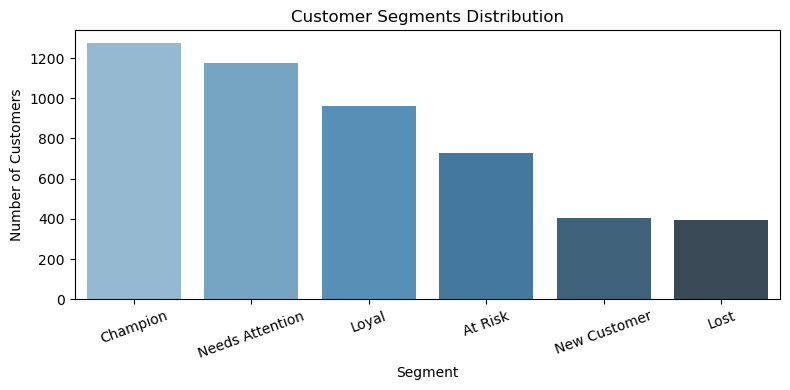

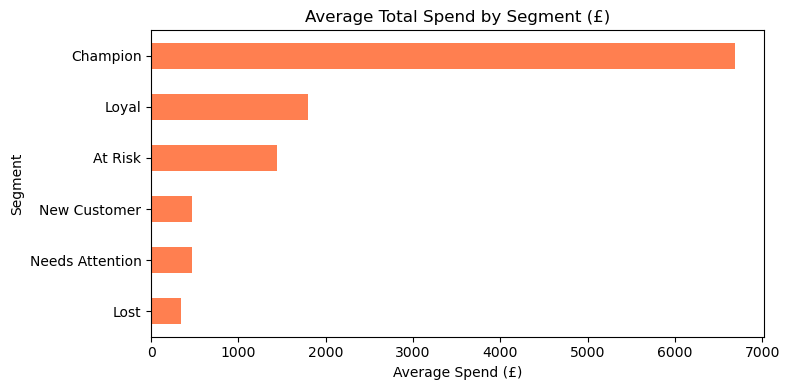

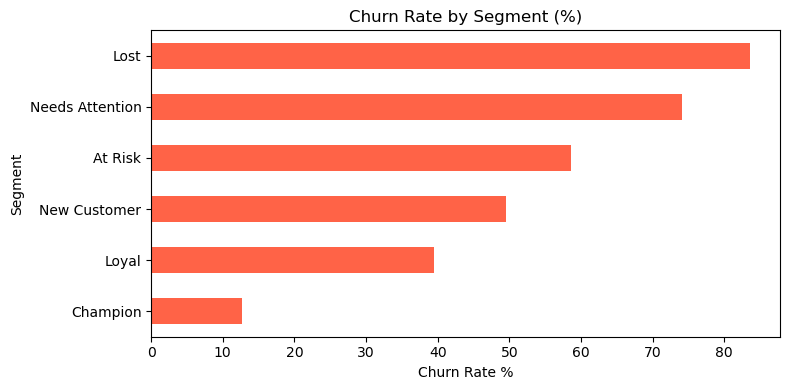

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 1: Add RFM scores back to rfm ──
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# ── Step 2: Add Segment labels back ──
def label_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    if r >= 4 and f >= 4: return 'Champion'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'New Customer'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r == 1 and f == 1: return 'Lost'
    else: return 'Needs Attention'

rfm['Segment'] = rfm.apply(label_customer, axis=1)
print("Segments created:")
print(rfm['Segment'].value_counts())

# ── Chart 1: Customer count per segment ──
plt.figure(figsize=(8,4))
order = rfm['Segment'].value_counts().index
sns.countplot(data=rfm, x='Segment', order=order, palette='Blues_d')
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('segments.png', dpi=150)  # saves image for your README
plt.show()

# ── Chart 2: Average spend per segment ──
plt.figure(figsize=(8,4))
avg_spend = rfm.groupby('Segment')['Monetary'].mean().sort_values()
avg_spend.plot(kind='barh', color='coral')
plt.title('Average Total Spend by Segment (£)')
plt.xlabel('Average Spend (£)')
plt.tight_layout()
plt.savefig('avg_spend.png', dpi=150)
plt.show()

# ── Chart 3: Churn rate per segment ──
plt.figure(figsize=(8,4))
churn_rate = rfm.groupby('Segment')['Churn'].mean() * 100
churn_rate.sort_values().plot(kind='barh', color='tomato')
plt.title('Churn Rate by Segment (%)')
plt.xlabel('Churn Rate %')
plt.tight_layout()
plt.savefig('churn_rate.png', dpi=150)
plt.show()

## Business Recommendations

1. FREQUENCY is the #1 churn driver (from SHAP analysis).
   Action: Send a second-purchase discount to all customers with ≤2 orders.

2. 2,367 customers (48%) are predicted to churn in the next 6 months.
   Action: Prioritise the "At Risk" segment for a re-engagement email campaign.

3. "Champion" customers should receive loyalty rewards — losing one
   Champion costs more than acquiring 5 new customers.